# 01 — Data Collection and Monthly Returns

## Objective

The objective of this notebook is to build a clean monthly price and return dataset
for the fixed universe of 24 European equities.

This dataset will be used later to construct the momentum factor
and run the portfolio backtest.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## 0. Fixed Universe

We use a fixed universe of 24 European large-cap stocks.

The universe is frozen at the beginning of the project
to ensure consistency and avoid selection bias.

In [2]:
TICKERS = ["AIR.PA", "BNP.PA", "SAN.PA", "MC.PA",
    "SAP.DE", "SIE.DE", "ALV.DE", "BAS.DE",
    "ASML.AS", "INGA.AS", "PHIA.AS", "AD.AS",
    "ENI.MI", "ISP.MI", "UCG.MI", "ENEL.MI",
    "IBE.MC", "SAN.MC", "BBVA.MC", "ITX.MC",
    "NESN.SW", "NOVN.SW", "ROG.SW", "UBSG.SW"]

print("Number of tickers:", len(TICKERS))
print(TICKERS)

Number of tickers: 24
['AIR.PA', 'BNP.PA', 'SAN.PA', 'MC.PA', 'SAP.DE', 'SIE.DE', 'ALV.DE', 'BAS.DE', 'ASML.AS', 'INGA.AS', 'PHIA.AS', 'AD.AS', 'ENI.MI', 'ISP.MI', 'UCG.MI', 'ENEL.MI', 'IBE.MC', 'SAN.MC', 'BBVA.MC', 'ITX.MC', 'NESN.SW', 'NOVN.SW', 'ROG.SW', 'UBSG.SW']


## 1. Download Daily Prices

We download daily adjusted close prices from Yahoo Finance
for the fixed European universe over 2010–2025.

## 2. Extract Adjusted Close Prices

We keep adjusted close prices because they provide a cleaner basis for return computation.

Adjusted prices correct for events such as:
- dividends
- stock splits

This makes return calculations more economically meaningful than using raw closing prices.

## 3. Initial Data Check

Before cleaning the dataset, we inspect:
- the panel dimensions
- the available dates
- the number of missing values by ticker

In [3]:
daily_data = yf.download(TICKERS,start="2010-01-01",end="2025-12-31",auto_adjust=False,progress=True)
adj_close = daily_data["Adj Close"].copy()
adj_close.head()

[*********************100%***********************]  24 of 24 completed


Ticker,AD.AS,AIR.PA,ALV.DE,ASML.AS,BAS.DE,BBVA.MC,BNP.PA,ENEL.MI,ENI.MI,IBE.MC,...,NESN.SW,NOVN.SW,PHIA.AS,ROG.SW,SAN.MC,SAN.PA,SAP.DE,SIE.DE,UBSG.SW,UCG.MI
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,5.496812,11.271766,41.426888,26.868116,21.354877,5.142893,26.580851,1.698947,6.389859,3.157323,...,31.571404,22.949162,12.853300,101.178200,4.556277,29.937416,25.522676,32.065174,10.452637,49.476540
2010-01-05,5.450763,11.235508,41.553211,26.917948,21.031097,5.178578,26.529774,1.695823,6.435752,3.161076,...,30.827816,22.553116,12.826398,99.834389,4.606643,29.541765,25.294107,32.084766,10.541324,48.751995
2010-01-06,5.481656,11.336220,41.876060,27.205896,21.164419,5.198406,26.571566,1.724989,6.442813,3.156855,...,30.338284,22.595224,12.629066,100.506317,4.639574,29.372961,25.743500,32.202316,10.471642,48.337955
2010-01-07,5.361578,11.449018,41.394142,26.707525,21.023960,5.174615,27.035950,1.741655,6.481647,3.136680,...,29.991280,22.428049,12.557307,99.666412,4.618265,29.520670,26.425348,32.584339,10.503317,49.476540
2010-01-08,5.416954,11.561817,41.169552,25.810442,20.959682,5.214268,27.676771,1.748947,6.485177,3.133397,...,30.431232,22.428049,12.575252,99.946388,4.633764,29.357136,26.611309,32.790035,10.902416,49.942322


In [4]:
print("Daily price panel shape:", adj_close.shape)
print("Start date:", adj_close.index.min())
print("End date:", adj_close.index.max())
print("\nMissing values by ticker (daily data):")
print(adj_close.isna().sum().sort_values(ascending=False))

Daily price panel shape: (4098, 24)
Start date: 2010-01-04 00:00:00
End date: 2025-12-30 00:00:00

Missing values by ticker (daily data):
Ticker
ROG.SW     78
UBSG.SW    78
NOVN.SW    78
NESN.SW    78
ALV.DE     34
BAS.DE     34
ENEL.MI    34
SIE.DE     34
UCG.MI     34
SAP.DE     34
ENI.MI     34
ISP.MI     34
BBVA.MC     6
SAN.MC      6
IBE.MC      6
ITX.MC      6
SAN.PA      5
MC.PA       5
BNP.PA      5
AIR.PA      5
AD.AS       4
ASML.AS     4
INGA.AS     4
PHIA.AS     4
dtype: int64


## Interpretation of Missing Values

A small number of missing observations is expected because:
- exchanges have different holidays
- some historical series may start later
- market data providers may contain gaps

The objective is to make sure there are no massive missing-value issues
before constructing the monthly panel.

## 4. Daily Data Cleaning

Before converting prices to monthly frequency, we apply a simple cleaning procedure.

We do two things:

1. Sort dates in chronological order  
   This ensures the time series is correctly ordered before any transformation.

2. Forward-fill small missing values  
   If a price is missing on a given day, we replace it with the last available observed price.

This helps align data across countries with different trading calendars.

In [5]:
# Ensure dates are correctly ordered
adj_close = adj_close.sort_index()

# Fill small gaps with the last available observed price
adj_close = adj_close.ffill()

print("Missing values by ticker after forward fill:")
print(adj_close.isna().sum().sort_values(ascending=False))

Missing values by ticker after forward fill:
Ticker
AD.AS      0
AIR.PA     0
ALV.DE     0
ASML.AS    0
BAS.DE     0
BBVA.MC    0
BNP.PA     0
ENEL.MI    0
ENI.MI     0
IBE.MC     0
INGA.AS    0
ISP.MI     0
ITX.MC     0
MC.PA      0
NESN.SW    0
NOVN.SW    0
PHIA.AS    0
ROG.SW     0
SAN.MC     0
SAN.PA     0
SAP.DE     0
SIE.DE     0
UBSG.SW    0
UCG.MI     0
dtype: int64


## 5. Monthly Price Panel

We convert daily prices to monthly prices by keeping
the last available trading price of each month.

## 6. Check Monthly Prices

We verify that the monthly panel is correctly structured
and inspect remaining missing values.

In [6]:
monthly_prices = adj_close.resample("ME").last()
print(monthly_prices.head())

print("Monthly price panel shape:", monthly_prices.shape)
print("\nMissing values by ticker (monthly prices):")
print(monthly_prices.isna().sum().sort_values(ascending=False))
print(monthly_prices.tail())

Ticker         AD.AS     AIR.PA     ALV.DE    ASML.AS     BAS.DE   BBVA.MC  \
Date                                                                         
2010-01-31  5.303871  11.440961  37.627632  25.439426  19.628864  4.401397   
2010-02-28  5.246161  12.210407  39.676983  24.929981  19.636015  3.786786   
2010-03-31  5.753290  12.000923  43.434128  29.493330  21.864344  4.016770   
2010-04-30  6.150913  11.303990  40.481747  27.698772  21.745588  3.996092   
2010-05-31  6.103231  13.124877  40.023129  26.260885  21.290699  3.424188   

Ticker         BNP.PA   ENEL.MI    ENI.MI    IBE.MC  ...    NESN.SW  \
Date                                                 ...              
2010-01-31  24.217184  1.626032  5.976814  2.899296  ...  31.292551   
2010-02-28  24.672274  1.659364  5.849722  2.774503  ...  33.120541   
2010-03-31  26.404390  1.724989  6.132146  2.943864  ...  33.461346   
2010-04-30  24.207895  1.646865  5.952102  2.810158  ...  33.767170   
2010-05-31  22.172819  1.55

## 7. Monthly Returns

We compute simple monthly returns from month-end prices.

The return formula is:

R_t = P_t / P_{t-1} - 1

In [7]:
monthly_returns = monthly_prices.pct_change() #This pandas function computes percentage returns between consecutive observations.
monthly_returns = monthly_returns.dropna(how="all") #We remove rows where all values are missing. This typically corresponds to the first observation, for which returns cannot be computed.
monthly_returns.head()

Ticker,AD.AS,AIR.PA,ALV.DE,ASML.AS,BAS.DE,BBVA.MC,BNP.PA,ENEL.MI,ENI.MI,IBE.MC,...,NESN.SW,NOVN.SW,PHIA.AS,ROG.SW,SAN.MC,SAN.PA,SAP.DE,SIE.DE,UBSG.SW,UCG.MI
Date,,,,,,,,,,,,,,,,,,,,,
2010-02-28,-0.010881,0.067254,0.054464,-0.020026,0.000364,-0.139640,0.018792,0.020499,-0.021264,-0.043042,...,0.058416,0.051030,-0.019635,0.005042,-0.061713,0.002239,-0.009674,-0.021003,0.055595,-0.080693
2010-03-31,0.096667,-0.017156,0.094693,0.183047,0.113482,0.060733,0.070205,0.039548,0.048280,0.061042,...,0.010290,-0.005490,0.137773,-0.014997,0.030474,0.027364,0.094628,0.177171,0.157326,0.177975
2010-04-30,0.069112,-0.058073,-0.067974,-0.060846,-0.005431,-0.005148,-0.083187,-0.045290,-0.029361,-0.045418,...,0.009140,-0.033380,0.071188,-0.005263,-0.029471,-0.063961,0.010178,0.002562,-0.015752,-0.088457
2010-05-31,-0.007752,0.161084,-0.011329,-0.051912,-0.020919,-0.143116,-0.084067,-0.054396,-0.068506,-0.099833,...,-0.008515,-0.046304,-0.040897,-0.067020,-0.107543,0.005376,-0.027605,-0.004305,-0.079431,-0.112241
2010-06-30,-0.007324,0.035605,0.005775,-0.029499,0.047608,0.010798,-0.032941,-0.029506,-0.000658,-0.109475,...,-0.003817,0.001886,0.013530,-0.060491,0.049850,0.001618,0.056003,0.000000,-0.068899,0.056897


## 8. Final Validation

We validate that the monthly return matrix is usable for the next steps of the project:
- rows = monthly dates
- columns = tickers
- values = monthly returns
- no massive missing values

## 9. Visual Check

We plot one monthly price series as a quick sanity check.

Monthly returns panel shape: (191, 24)

Missing values by ticker (monthly returns):
Ticker
AD.AS      0
AIR.PA     0
ALV.DE     0
ASML.AS    0
BAS.DE     0
BBVA.MC    0
BNP.PA     0
ENEL.MI    0
ENI.MI     0
IBE.MC     0
INGA.AS    0
ISP.MI     0
ITX.MC     0
MC.PA      0
NESN.SW    0
NOVN.SW    0
PHIA.AS    0
ROG.SW     0
SAN.MC     0
SAN.PA     0
SAP.DE     0
SIE.DE     0
UBSG.SW    0
UCG.MI     0
dtype: int64


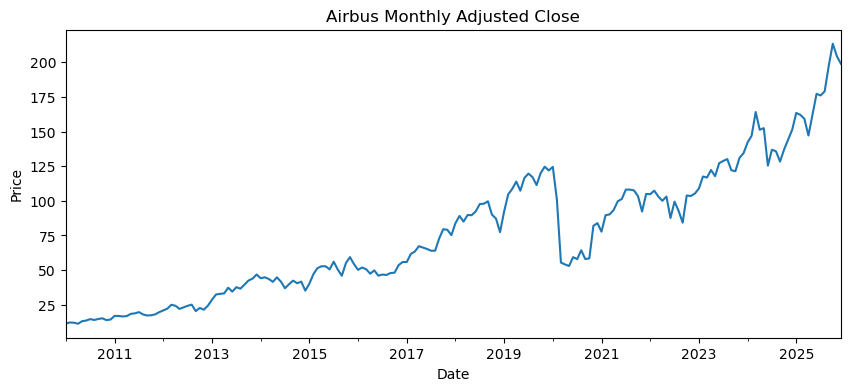

In [8]:
print("Monthly returns panel shape:", monthly_returns.shape)
print("\nMissing values by ticker (monthly returns):")
print(monthly_returns.isna().sum().sort_values(ascending=False))

monthly_prices["AIR.PA"].plot(figsize=(10, 4), title="Airbus Monthly Adjusted Close")
plt.ylabel("Price")
plt.show()

## Conclusion

In this notebook, I built the data foundation for the momentum strategy:

- daily adjusted close prices were downloaded for the fixed universe
- the panel was cleaned and aligned
- prices were resampled to month-end frequency
- monthly returns were computed

This monthly return matrix is the key input for the next step:
constructing the momentum 12-1 signal.